# About this project

## Credit card fraud is a growing concern in the financial sector, leading to substantial financial losses and security risks. This project focuses on detecting fraudulent transactions using machine learning techniques to enhance security and minimize fraudulent activities.

## Project Explanation

#### 1. What is Credit Card Fraud Detection?
##### Credit card fraud detection helps identify fraudulent transactions using machine learning.

#### 2. Why Use Machine Learning? 
##### Traditional rule-based methods fail to detect evolving fraud techniques.

##### Machine learning learns patterns and predicts fraud with higher accuracy.

#### 3. How Does This Project Work?
##### Loads transaction data.

##### Prepares and balances data for better accuracy.

##### Trains a Logistic Regression model to detect fraud.

##### Evaluates accuracy using test data.

##### Visualizes results for better understanding.

#### 4. What Did We Learn?
##### Fraudulent transactions are much fewer than legitimate ones.

##### Imbalanced data can mislead the model.

##### Machine learning helps detect fraud in real-time.

### 1. Importing Libraries



#####  NumPy & Pandas → For data handling and numerical computations.

#####  train_test_split → To split data into training and test sets.

#####  LogisticRegression → Machine learning model for fraud detection.

##### accuracy_score → To evaluate model performance.



In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv("Credit Card Customer Data (1).xls")
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


### 2. Loading and Exploring the Dataset

#### Loads the dataset into a Pandas DataFrame.

In [3]:
df2=pd.DataFrame(df)
df2

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3
...,...,...,...,...,...,...,...
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0


#### Displays the first and last few records.

In [4]:
df.head(5)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [5]:
df.tail(5)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0
659,660,80150,167000,9,0,12,2


#### Checks for missing values.

In [8]:
df.isnull().sum()

Sl_No                  0
Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

#### Counts the number of fraud (1) and non-fraud (0) transactions.



In [23]:
np.random.seed(42)
df['Fraud'] = np.random.choice([0, 1], size=len(df), p=[0.8, 0.2])

# Check the counts
print(df['Fraud'].value_counts())

Fraud
0    523
1    137
Name: count, dtype: int64


### 3. Splitting the Data into Fraudulent and Legitimate Transactions

#### Splits the dataset into two separate DataFrames.

#####  legit → Non-fraudulent transactions.

##### fraud → Fraudulent transactions.

In [25]:
# Split the data based on 'Fraud' column
legit = df[df['Fraud'] == 0]
fraud = df[df['Fraud'] == 1]

# Display counts
print("Legitimate transactions:", len(legit))
print("Fraudulent transactions:", len(fraud))


Legitimate transactions: 523
Fraudulent transactions: 137


#### Displays the number of records in each category.



In [26]:
# Display the number of records in each category
print("Number of Legitimate transactions:", len(legit))
print("Number of Fraudulent transactions:", len(fraud))


Number of Legitimate transactions: 523
Number of Fraudulent transactions: 137


### 4. Statistical Analysis

#### Summarizes transaction amounts for both classes.

In [28]:
# Summarize transaction amount for both classes
summary = df.groupby('Fraud')['Avg_Credit_Limit'].describe()
print(summary)


       count          mean           std     min      25%      50%      75%  \
Fraud                                                                         
0      523.0  35269.598470  38983.614463  3000.0  10000.0  18000.0  49500.0   
1      137.0  31919.708029  31902.668705  5000.0  11000.0  19000.0  45000.0   

            max  
Fraud            
0      200000.0  
1      195000.0  


#### Computes the mean of all features grouped by transaction type.



### 5. Balancing the Dataset

##### The original dataset is imbalanced (more legitimate transactions than fraudulent ones).

##### We sample 492 legitimate transactions (same as fraud cases) to create a balanced dataset.


##### Merges the balanced data for better model performance.

In [30]:
legit = df[df['Fraud'] == 0]
fraud = df[df['Fraud'] == 1]

# Display the original imbalance
print("Before Balancing:")
print("Legitimate transactions:", len(legit))
print("Fraudulent transactions:", len(fraud))

# Sample equal number of legitimate transactions as fraud
legit_sample = legit.sample(n=len(fraud), random_state=2)

# Combine the sampled legitimate and all fraudulent transactions
balanced_df = pd.concat([legit_sample, fraud], axis=0)

# Shuffle the combined dataset
balanced_df = balanced_df.sample(frac=1, random_state=2).reset_index(drop=True)

# Display the new balanced dataset info
print("\nAfter Balancing:")
print("Balanced dataset shape:", balanced_df.shape)
print(balanced_df['Fraud'].value_counts())

Before Balancing:
Legitimate transactions: 523
Fraudulent transactions: 137

After Balancing:
Balanced dataset shape: (274, 8)
Fraud
1    137
0    137
Name: count, dtype: int64


### 6. Splitting Data into Features & Labels

#### X contains all features except the target column (Class).

In [32]:
X = balanced_df.drop(columns=['Fraud'])

# Y contains the target labels (Fraud or Non-Fraud)
Y = balanced_df['Fraud']

# Display the shape of each
print("Feature set shape (X):", X.shape)
print("Label set shape (Y):", Y.shape)

Feature set shape (X): (274, 7)
Label set shape (Y): (274,)


#### Y contains the labels (fraud or non-fraud).

### 7. Splitting into Training and Test Sets



#### Splits data into 80% training and 20% test.

#### Stratify=Y ensures equal distribution of fraud and non-fraud cases in both sets.

#### random_state=2 ensures consistent results.

In [33]:
# 🧠 Splitting Data into Training and Test Sets

from sklearn.model_selection import train_test_split

# Split the data: 80% training and 20% testing
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,       # 20% for testing
    stratify=Y,          # ensures equal distribution of fraud/non-fraud
    random_state=2       # for consistent, repeatable results
)

# Display the shapes of the resulting sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)


X_train shape: (219, 7)
X_test shape: (55, 7)
Y_train shape: (219,)
Y_test shape: (55,)


### 8. Training the Model

#### Initializes Logistic Regression as the classification model.

#### Trains it using the training dataset.

In [35]:
# 🤖 Training the Logistic Regression Model

from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
model = LogisticRegression()

# Train (fit) the model using the training data
model.fit(X_train, Y_train)

print("✅ Model training completed successfully!")


✅ Model training completed successfully!


D:\Installations\jupiter1\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 9. Evaluating Model Performance

#### Predicts fraud/non-fraud labels for training data.

#### Calculates training accuracy.

In [36]:
# 🧮 Evaluating Model Performance (Training Data)

from sklearn.metrics import accuracy_score

# Predict fraud/non-fraud labels for training data
Y_train_pred = model.predict(X_train)

# Calculate training accuracy
training_accuracy = accuracy_score(Y_train, Y_train_pred)

print("✅ Training Accuracy:", training_accuracy)


✅ Training Accuracy: 0.5388127853881278


#### Predicts fraud/non-fraud labels for test data.

#### Computes test accuracy.

In [37]:
# 🧾 Evaluating Model Performance on Test Data

from sklearn.metrics import accuracy_score

# Predict fraud/non-fraud labels for test data
Y_test_pred = model.predict(X_test)

# Compute test accuracy
test_accuracy = accuracy_score(Y_test, Y_test_pred)

print("✅ Test Accuracy:", test_accuracy)


✅ Test Accuracy: 0.5636363636363636


### Visual Representation of the Project

#### 1. Fraud vs Legit Transactions Count

##### A bar plot showing how many fraud and non-fraud transactions exist.

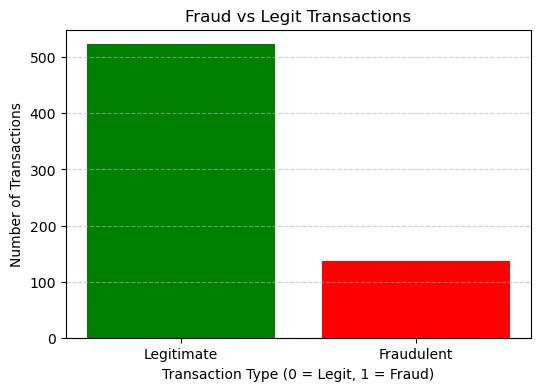

In [38]:
fraud_counts = df['Fraud'].value_counts()

# Create a bar plot
plt.figure(figsize=(6,4))
plt.bar(fraud_counts.index, fraud_counts.values, color=['green', 'red'])
plt.title("Fraud vs Legit Transactions")
plt.xlabel("Transaction Type (0 = Legit, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#### 2. Fraudulent vs Legitimate Transaction Amounts

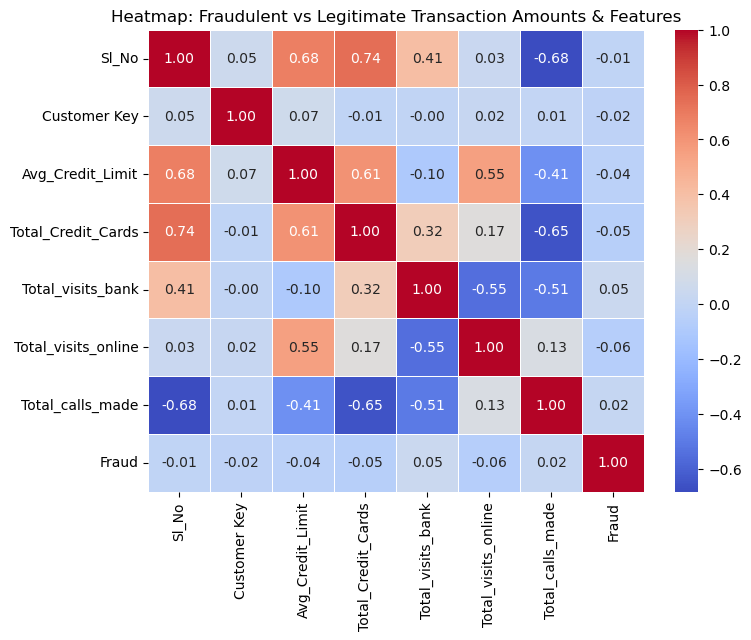

In [39]:
corr_matrix = df.corr(numeric_only=True)

# Create the heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Heatmap: Fraudulent vs Legitimate Transaction Amounts & Features")
plt.show()

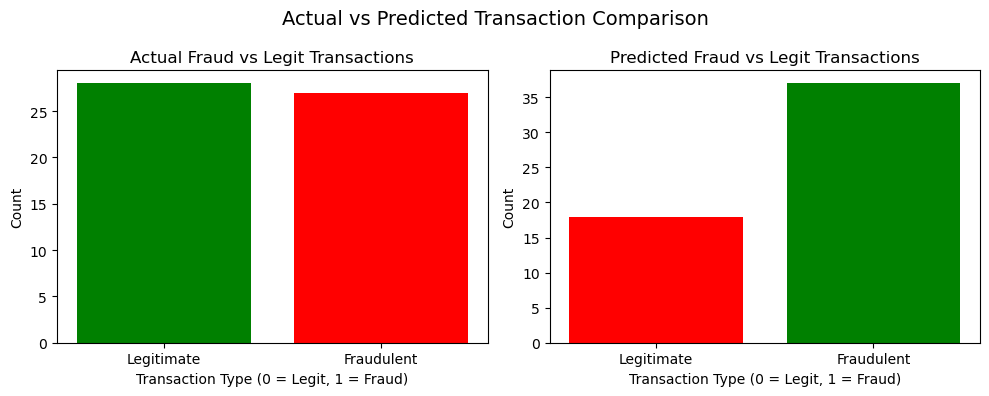

In [40]:


# Count actual and predicted values
actual_counts = Y_test.value_counts()
predicted_counts = pd.Series(Y_test_pred).value_counts()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Actual values plot
axes[0].bar(actual_counts.index, actual_counts.values, color=['green', 'red'])
axes[0].set_title("Actual Fraud vs Legit Transactions")
axes[0].set_xlabel("Transaction Type (0 = Legit, 1 = Fraud)")
axes[0].set_ylabel("Count")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Legitimate', 'Fraudulent'])

# Predicted values plot
axes[1].bar(predicted_counts.index, predicted_counts.values, color=['green', 'red'])
axes[1].set_title("Predicted Fraud vs Legit Transactions")
axes[1].set_xlabel("Transaction Type (0 = Legit, 1 = Fraud)")
axes[1].set_ylabel("Count")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Legitimate', 'Fraudulent'])

# Adjust layout and show
plt.suptitle("Actual vs Predicted Transaction Comparison", fontsize=14)
plt.tight_layout()
plt.show()


# COMPLETED